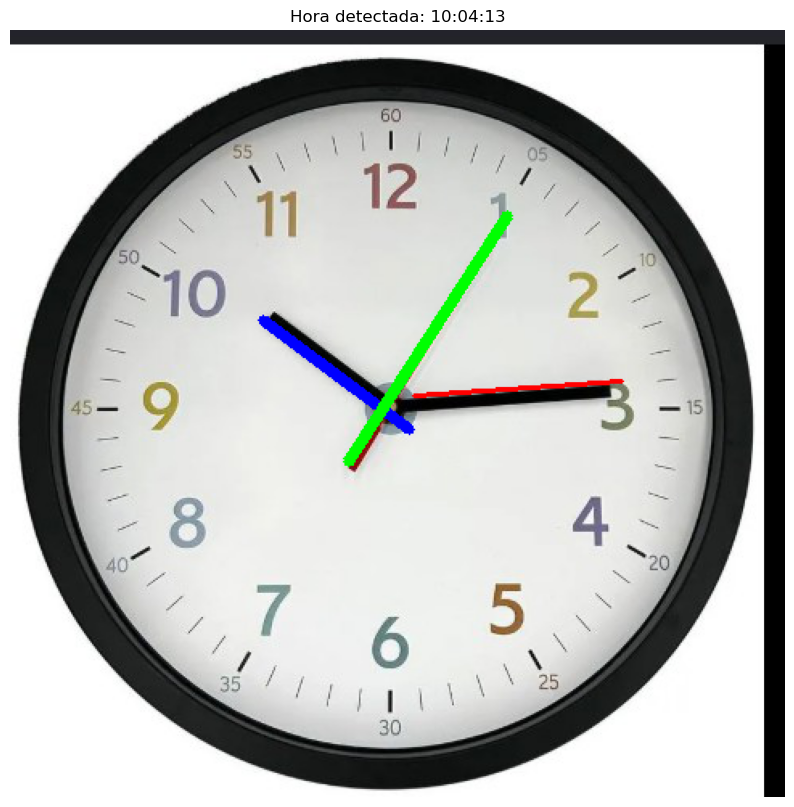

La hora detectada es: 10:04:13


In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('reloj4.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

# detección de bordes
bordes = cv2.Canny(gris, 50, 150)

#  líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

# centro del reloj
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

# calcular ángulo
def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        if distancia_centro < 100 and 40 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

# nuevas implementaciones------------------------------------------------------------------------------------------


def alcance_al_centro(x1, y1, x2, y2):
    d1 = np.hypot(x1 - centro_x, y1 - centro_y)
    d2 = np.hypot(x2 - centro_x, y2 - centro_y)
    return max(d1, d2)

# Agregar el alcance a cada manecilla detectada
for m in manecillas:
    x1, y1, x2, y2 = m['puntos']
    m['alcance'] = alcance_al_centro(x1, y1, x2, y2)
# Agrupar líneas que tengan orientación parecida
# Porque Hough puede detectar varias líneas de una misma manecilla
def agrupar_por_angulo(candidatas, tolerancia=15):
    grupos = []
    usadas = [False] * len(candidatas)

    for i, c in enumerate(candidatas):
        if usadas[i]:
            continue

        grupo = [c]
        usadas[i] = True

        for j, d in enumerate(candidatas):
            if usadas[j]:
                continue

            diff = abs(c['angulo'] - d['angulo'])
            diff = min(diff, 360 - diff)

            if diff < tolerancia:
                grupo.append(d)
                usadas[j] = True

        # Nos quedamos con la línea de mayor alcance dentro del grupo
        mejor = max(grupo, key=lambda x: x['alcance'])
        grupos.append(mejor)

    return grupos

# Reemplazar la lista original por los grupos ya depurados
manecillas = agrupar_por_angulo(manecillas, tolerancia=15)



if len(manecillas) >= 3: # n modificamos a 3
    # más corta = horario, más larga = minutero
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[0]
    minutero = manecillas[-1]
    segundero = manecillas[1]    # intermedio nuevo

    # hora y minutos
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60) # nuevo

    # la hora
    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12


    imagen_resultado = imagen_rgb.copy()
   # cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (0, 0, 255), 5)  
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 5)  
    #nuevo
    cv2.line(imagen_resultado,
             (segundero['puntos'][0], segundero['puntos'][1]),
             (segundero['puntos'][2], segundero['puntos'][3]),
             (255, 0, 0), 2)


    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora detectada: {hora}:{minutos:02d}:{segundos:02d}')
    plt.axis('off')
    plt.show()

    print(f"La hora detectada es: {hora}:{minutos:02d}:{segundos:02d}")
    
else:
    print(f"Solo se detectaron {len(manecillas)} manecilla(s). Se necesitan al menos 3.")
